# CNOT sheetcopy
This file contains analysis for CNOT sheetcopy results (both the initial scan and the full scan).

### Initial scan

In [1]:
%load_ext autoreload
%autoreload 2

# Initial scan
from analysis_utils import load_ft_scan, plot_rate_scan

initial_scan = load_ft_scan(
    "../results/cnot_sheetcopy/initial_scan",
    p_values=[0.006, 0.008, 0.01, 0.012, 0.014, 0.016],
    L_values=[5, 7, 9, 13],
    expected_repeats=1,
)
initial_scan.print_summary()


Loaded 24 requested CNOT Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13]
p values: [0.006 0.008 0.01  0.012 0.014 0.016]
repeat counts:
 [[1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]]


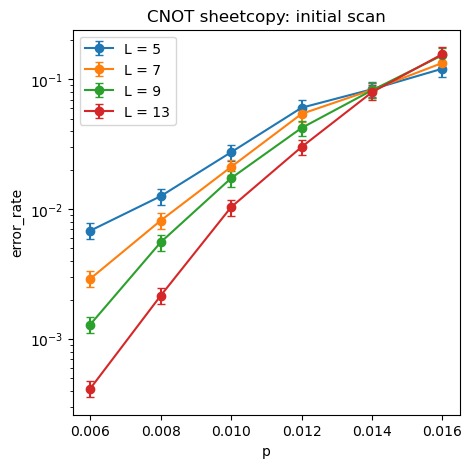

In [2]:
plot_rate_scan(
    initial_scan,
    title="CNOT sheetcopy: initial scan",
    ylabel="error_rate",
)


### Full scan

In [3]:
# Full scan
from analysis_utils import fit_scaling_ansatz, print_scaling_ansatz_fit

full_scan = load_ft_scan(
    "../results/cnot_sheetcopy/full_scan/T∕2_CNOT_T∕2_2T",
    p_values=[0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.020],
    L_values=[5, 7, 9, 13, 19],
    expected_repeats=5,
)
full_scan.print_summary()


Loaded 497 requested CNOT Ft files; ignored 80 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[10 10 10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10 10 10]
 [ 7 10 10 10 10 10 10 10 10 10]]


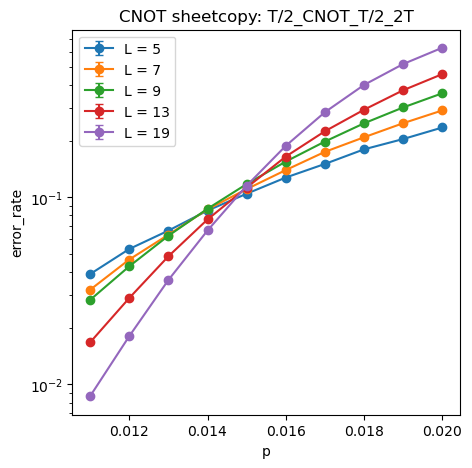

In [4]:
plot_rate_scan(
    full_scan,
    title="CNOT sheetcopy: T/2_CNOT_T/2_2T",
    ylabel="error_rate",
)


In [5]:
# Flattened arrays remain convenient for ad-hoc interactive fits.
p, L, rate, rate_error = full_scan.fit_arrays()


In [6]:
quadratic_fit = fit_scaling_ansatz(full_scan, polynomial_order=2)
print_scaling_ansatz_fit(quadratic_fit)


Fitted parameters: [1.44115773e-02 1.38866407e+00 9.61046999e-02 6.12461095e+00
 1.08535899e+02]
Parameter standard deviations: [1.19296751e-05 6.74392985e-03 4.05391488e-04 5.68947390e-02
 1.90946710e+00]
Weighted absolute residual: 224.89221282444637


In [7]:
cubic_fit = fit_scaling_ansatz(full_scan, polynomial_order=3)
print_scaling_ansatz_fit(cubic_fit)


Fitted parameters: [1.45658567e-02 1.44147121e+00 9.77088789e-02 6.44573349e+00
 1.36695696e+02 7.17114385e+02]
Parameter standard deviations: [1.40047756e-05 7.42129872e-03 4.27320886e-04 5.95165591e-02
 2.65347047e+00 3.80035805e+01]
Weighted absolute residual: 183.1739654244538


In [8]:
quadratic_correction_fit = fit_scaling_ansatz(
    full_scan,
    polynomial_order=2,
    include_finite_size_correction=True,
)
print_scaling_ansatz_fit(quadratic_correction_fit)


Fitted parameters: [ 1.46655159e-02  1.34084850e+00  1.07628066e-01  6.07161987e+00
  9.40589458e+01 -6.43465949e+00  2.46072552e-01]
Parameter standard deviations: [3.15933635e-05 9.45584543e-03 1.57727672e-03 6.17462731e-02
 2.69190092e+00 6.60443606e+00 4.17425383e-02]
Weighted absolute residual: 188.4357881313914


In [9]:
cubic_correction_fit = fit_scaling_ansatz(
    full_scan,
    polynomial_order=3,
    include_finite_size_correction=True,
)
print_scaling_ansatz_fit(cubic_correction_fit)


Fitted parameters: [ 1.49992607e-02  1.34083530e+00  1.18443605e-01  6.27664226e+00
  1.07706661e+02  4.82797561e+02 -5.47021314e-01  4.41761280e-01]
Parameter standard deviations: [5.32497948e-05 1.37804440e-02 3.01101715e-03 7.10245628e-02
 3.97564141e+00 2.96980123e+01 2.15774805e-01 6.19367718e-02]
Weighted absolute residual: 135.4954508772461


In [10]:
import numpy as np

px = 0.16
w1 = np.log(1/px - 1)
print(w1)

1.6582280766035324
